In [4]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
def load_image(path):
    image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError(f"Error cargando imagen: {path}")
    return image

In [6]:
def remove_black_background(image, threshold=5):
    """
    Recorta bordes negros automáticamente.
    """
    _, thresh = cv2.threshold(image, threshold, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(thresh)
    x, y, w, h = cv2.boundingRect(coords)
    cropped = image[y:y+h, x:x+w]
    return cropped

In [8]:
def apply_clahe(image, clip_limit=2.0, tile_grid_size=(8,8)):
    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=tile_grid_size
    )
    cl = clahe.apply(image)
    return cl

In [7]:
def normalize_and_expand(image):
    """
    Normaliza a [0,1] y convierte a 3 canales.
    """
    image = image.astype(np.float32) / 255.0
    image = np.stack([image]*3, axis=-1)
    return image

In [9]:
def get_breast_bbox(image, threshold=5):
    """
    Calcula bounding box del tejido mamario.
    """
    _, thresh = cv2.threshold(image, threshold, 255, cv2.THRESH_BINARY)
    
    coords = cv2.findNonZero(thresh)
    if coords is None:
        return None  # imagen vacía
    
    x, y, w, h = cv2.boundingRect(coords)
    return x, y, w, h

In [10]:
def crop_image_and_mask(image, mask):
    """
    Recorta imagen y máscara usando el mismo bounding box.
    """
    bbox = get_breast_bbox(image)
    
    if bbox is None:
        return image, mask
    
    x, y, w, h = bbox
    
    image_cropped = image[y:y+h, x:x+w]
    mask_cropped  = mask[y:y+h, x:x+w]
    
    return image_cropped, mask_cropped

In [11]:
def preprocess_pair(image_path, mask_path):
    
    # Cargar
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    mask  = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    # Binarizar máscara
    mask = (mask > 0).astype(np.uint8)
    
    # Recorte conjunto
    image, mask = crop_image_and_mask(image, mask)
    
    # CLAHE SOLO a imagen
    image = apply_clahe(image)
    
    # Normalizar
    image = image.astype(np.float32) / 255.0
    
    # Expandir canales
    image = np.stack([image]*3, axis=-1)
    
    return image, mask

In [12]:
def show_pair(image, mask):
    plt.figure(figsize=(12,5))
    
    plt.subplot(1,2,1)
    plt.title("Imagen")
    plt.imshow(image[:,:,0], cmap="gray")
    plt.axis("off")
    
    plt.subplot(1,2,2)
    plt.title("Máscara")
    plt.imshow(mask, cmap="gray")
    plt.axis("off")
    
    plt.show()

In [13]:
df = pd.read_excel("mass_case_train.xlsx")

In [14]:
[image, mask] = preprocess_pair("../"+df.iloc[4]["full_mammogram_img_path"], "../"+df.iloc[4]["roi_image_img_path"])

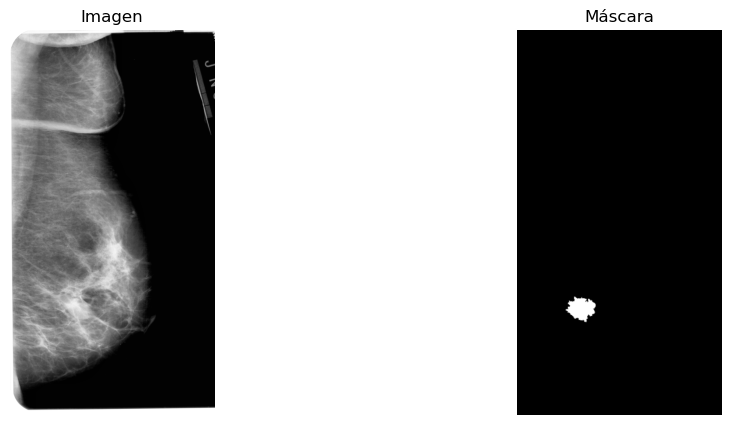

In [15]:
show_pair(image, mask)

In [16]:
def get_roi_bbox(mask):
    coords = np.column_stack(np.where(mask > 0))
    if len(coords) == 0:
        return None
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    return x_min, y_min, x_max, y_max

In [17]:
def extract_patch(image, center_x, center_y, patch_size=224):
    h, w = image.shape[:2]
    half = patch_size // 2
    
    x1 = max(center_x - half, 0)
    y1 = max(center_y - half, 0)
    x2 = x1 + patch_size
    y2 = y1 + patch_size
    
    # Ajustar si se sale del borde
    if x2 > w:
        x2 = w
        x1 = w - patch_size
    if y2 > h:
        y2 = h
        y1 = h - patch_size
    
    patch = image[y1:y2, x1:x2]
    
    if patch.shape[0] != patch_size or patch.shape[1] != patch_size:
        return None
    
    return patch

In [18]:
def is_mostly_black(patch, black_threshold=0.90):
    """
    Detecta si un patch tiene demasiado fondo negro.
    black_threshold = proporción máxima permitida de píxeles negros.
    """
    if len(patch.shape) == 3:
        gray = patch[:, :, 0]
    else:
        gray = patch
    
    # Si trabajas en [0,1]
    black_ratio = np.sum(gray < 0.05) / gray.size
    
    return black_ratio > black_threshold


def generate_patches(image, mask, patch_size=224, num_negative=2,
                     black_threshold=0.90):
    
    patches = []
    labels = []
    
    h, w = mask.shape
    
    # -------------------------
    # POSITIVE PATCH
    # -------------------------
    bbox = get_roi_bbox(mask)
    
    if bbox is not None:
        x_min, y_min, x_max, y_max = bbox
        center_x = (x_min + x_max) // 2
        center_y = (y_min + y_max) // 2
        
        pos_patch = extract_patch(image, center_x, center_y, patch_size)
        
        if pos_patch is not None:
            if not is_mostly_black(pos_patch, black_threshold):
                patches.append(pos_patch)
                labels.append(1)
    
    # -------------------------
    # NEGATIVE PATCHES
    # -------------------------
    for _ in range(num_negative):
        for _ in range(100):  # más intentos para asegurar patch válido
            
            rand_x = np.random.randint(patch_size//2, w - patch_size//2)
            rand_y = np.random.randint(patch_size//2, h - patch_size//2)
            
            # Asegurar que no esté en ROI
            if mask[rand_y, rand_x] == 0:
                
                neg_patch = extract_patch(image, rand_x, rand_y, patch_size)
                
                if neg_patch is None:
                    continue
                
                # Filtrar negro excesivo
                if is_mostly_black(neg_patch, black_threshold):
                    continue
                
                patches.append(neg_patch)
                labels.append(0)
                break
    
    return patches, labels

In [19]:
test_img_path = "../"+df.iloc[4]["full_mammogram_img_path"]
test_mask_path = "../"+df.iloc[4]["roi_image_img_path"]

image, mask = preprocess_pair(test_img_path, test_mask_path)

patches, labels = generate_patches(image, mask)

In [22]:
def show_patches(patches, labels):
    plt.figure(figsize=(12,4))
    for i, (patch, label) in enumerate(zip(patches, labels)):
        plt.subplot(1, len(patches), i+1)
        plt.imshow(patch[:,:,0], cmap="gray")
        plt.title("POS" if label==1 else "NEG")
        plt.axis("off")
    plt.show()

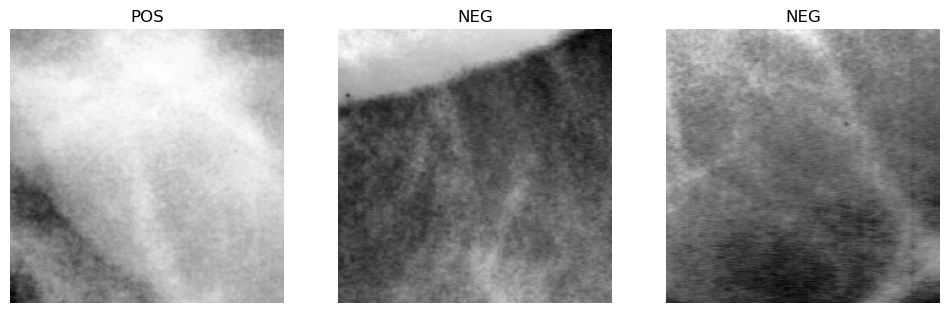

In [23]:
show_patches(patches, labels)

In [24]:
def preprocess_cropped(imagen, size=(224, 224)):
    """
    Preprocesamiento simple para imágenes recortadas
    Similar al usado en mammogramas completos
    """
    # Redimensionar
    img_resized = cv2.resize(imagen, size)
    
    # Normalizar a [0,1]
    img_normalized = img_resized.astype(np.float32) / 255.0
    
    return img_normalized

In [25]:
def roi_coverage(mask_patch):
    return np.sum(mask_patch) / mask_patch.size